<img src="./image/实验05.png" alt="实验03" style="zoom:50%;">

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chardet

In [3]:
# 加载中文字体，避免中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

1.(1)
{'encoding': 'GB2312', 'confidence': 0.99, 'language': 'Chinese'}


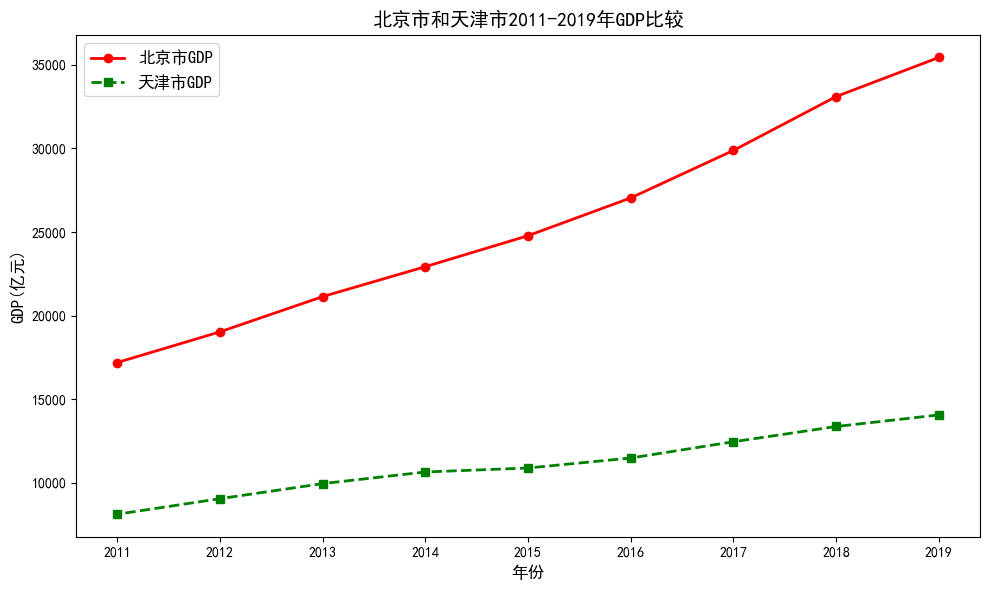

In [11]:
print('1.(1)')
# 读取数据
file = './data/分省年度数据.csv'
with open(file, 'rb') as f:
    result = chardet.detect(f.read())
    print(result)
data = pd.read_csv('./data/分省年度数据.csv', encoding=result['encoding'])

# 提取北京和天津的数据
beijing = data[data['地区'] == '北京市'].iloc[0, 1:].astype(float)
tianjin = data[data['地区'] == '天津市'].iloc[0, 1:].astype(float)
years = [int(year.replace('年', '')) for year in data.columns[1:]]

# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(years, beijing, label='北京市GDP', color='red',
          linestyle='-', linewidth=2, marker='o')
plt.plot(years, tianjin, label='天津市GDP', color='green',
          linestyle='--', linewidth=2, marker='s')
plt.title('北京市和天津市2011-2019年GDP比较', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('GDP(亿元)', fontsize=12)
plt.xticks(years)
# plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 显示图表
plt.tight_layout()
plt.show()

1.(2)


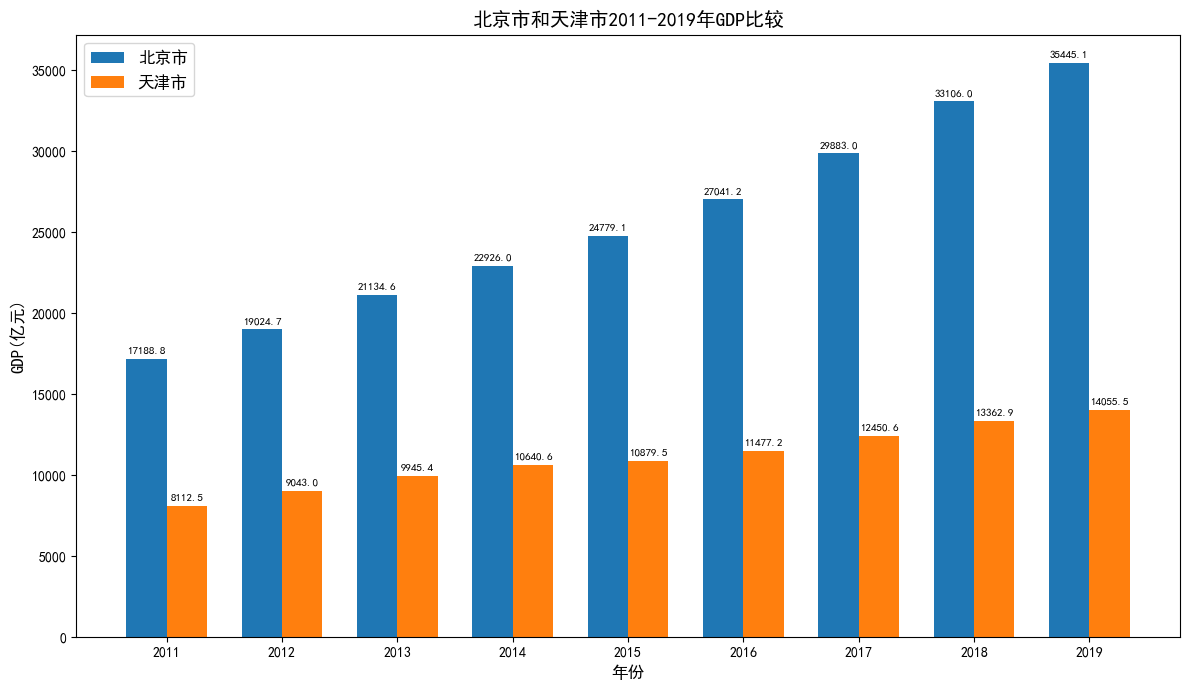

In [13]:
print('1.(2)')
# 准备数据
years_str = [str(year) for year in sorted(years)]
width = 0.35  # 柱状图宽度

# 创建子图
fig, ax = plt.subplots(figsize=(12, 7))

# 绘制柱状图
rects1 = ax.bar([x - width/2 for x in range(len(years))], 
               beijing.sort_index(), width, label='北京市')
rects2 = ax.bar([x + width/2 for x in range(len(years))], 
               tianjin.sort_index(), width, label='天津市')

# 设置图表属性
ax.set_title('北京市和天津市2011-2019年GDP比较', fontsize=14)
ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('GDP(亿元)', fontsize=12)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years_str)
ax.legend(fontsize=12)

# 添加数据标签
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

# 调整布局
fig.tight_layout()
plt.show()

2.


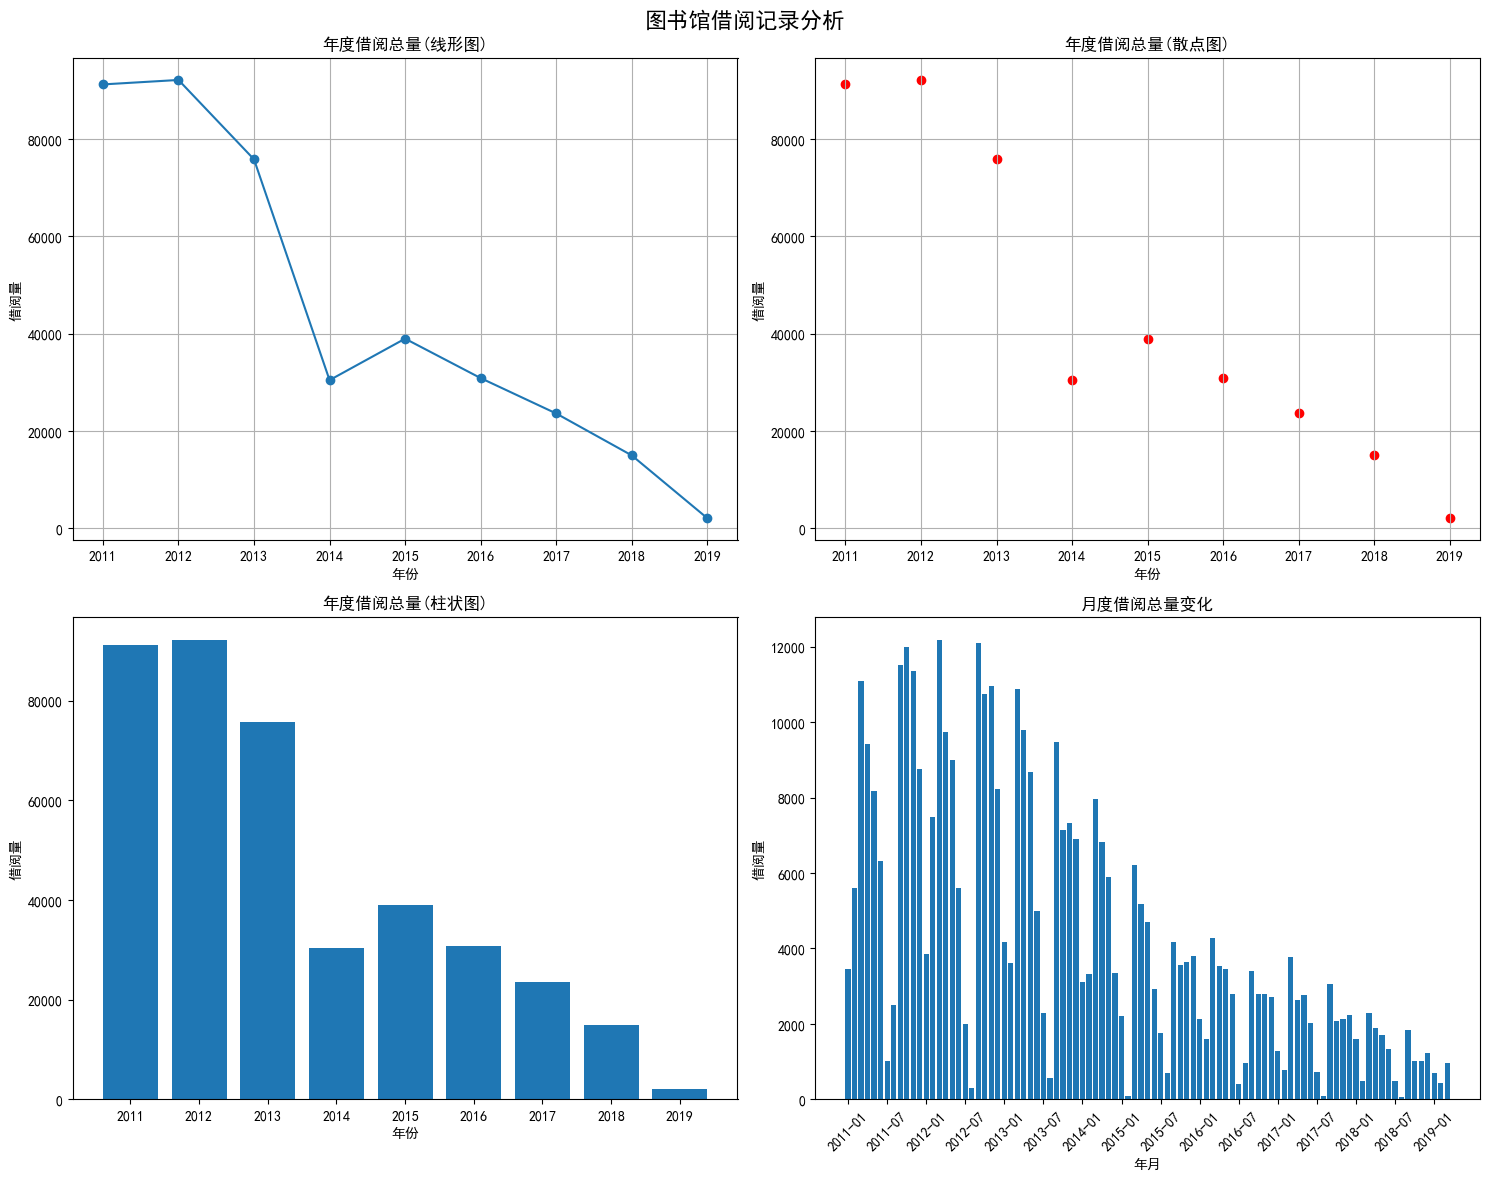

In [4]:
print('2.')
lending_df = pd.read_csv('./data/Lending.dat', encoding='utf-8')
lending_df['date'] = pd.to_datetime(lending_df['date'])

# 1. 年度借阅总量分析
# 转换日期格式并提取年份
lending_df['date'] = pd.to_datetime(lending_df['date'])
lending_df['year'] = lending_df['date'].dt.year
yearly_counts = lending_df['year'].value_counts().sort_index()

# 2. 月度借阅总量分析
lending_df['month'] = lending_df['date'].dt.to_period('M')
monthly_counts = lending_df['month'].value_counts().sort_index()

# 创建2x2的子图布局
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('图书馆借阅记录分析', fontsize=16)

# 线形图
axes[0, 0].plot(yearly_counts.index, yearly_counts.values, marker='o')
axes[0, 0].set_title('年度借阅总量(线形图)')
axes[0, 0].set_xlabel('年份')
axes[0, 0].set_ylabel('借阅量')
axes[0, 0].grid(True)

# 散点图
axes[0, 1].scatter(yearly_counts.index, yearly_counts.values, color='red')
axes[0, 1].set_title('年度借阅总量(散点图)')
axes[0, 1].set_xlabel('年份')
axes[0, 1].set_ylabel('借阅量')
axes[0, 1].grid(True)

# 年度柱状图
axes[1, 0].bar(yearly_counts.index, yearly_counts.values)
axes[1, 0].set_title('年度借阅总量(柱状图)')
axes[1, 0].set_xlabel('年份')
axes[1, 0].set_ylabel('借阅量')
axes[1, 0].set_xticks(yearly_counts.index)

# 月度柱状图
axes[1, 1].bar(monthly_counts.index.astype(str), monthly_counts.values)
axes[1, 1].set_title('月度借阅总量变化')
axes[1, 1].set_xlabel('年月')
axes[1, 1].set_ylabel('借阅量')
plt.xticks(rotation=45)

# 设置月度图x轴刻度 - 每6个月显示一次
month_labels = monthly_counts.index.astype(str)
axes[1, 1].set_xticks(np.arange(0, len(month_labels), 6))  # 每6个月一个刻度
axes[1, 1].set_xticklabels(month_labels[::6], rotation=45)  # 旋转45度防止重叠

# 调整布局
plt.tight_layout()
plt.show()